In [194]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [195]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Brain Tumor':1,'Healthy':0}

classes_in_dir

{'Brain Tumor': 1, 'Healthy': 0}

def safe_augment1(img):
    h, w = img.shape[:2]
    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)
    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]
    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)
    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)
    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)
    # 6. Always flip horizontally
    img = cv2.flip(img, 1)
    return img






In [196]:


def safe_mri_augment2(img):
    h, w = img.shape[:2]

    # 1. Very small rotation (simulate head tilt)
    angle = 3   # degrees
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Slight zoom (1–2%)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h) // 2, 0)
    start_x = max((zw - w) // 2, 0)
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Small brightness shift (+/- 5 intensity)
    beta = 5
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Gentle contrast/gamma adjustment (close to 1.0)
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Add very small Gaussian noise
    noise = np.random.normal(0, 2, img.shape).astype(np.int16)  # mean=0, std=2
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img


In [197]:

def safe_augment3(img):
    h, w = img.shape[:2]

    # 1. Small fixed rotation (3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Very small zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h) // 2, 0)
    start_x = max((zw - w) // 2, 0)
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild brightness adjustment (+5)
    beta = 5
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Slight gamma correction (1.02)
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Gentle Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always horizontal flip
    img = cv2.flip(img, 1)

    return img



In [198]:
def safe_mri_augment4(img):
    h, w = img.shape[:2]

    # 1. Small rotation (±3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Slight zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild contrast adjustment
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    return img


In [199]:
def safe_mri_augment4(img):
    h, w = img.shape[:2]

    # 1. Small rotation (±3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Slight zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild contrast adjustment
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    return img


       


In [200]:
# --------------------
# Augmentation function
# --------------------
def safe_mri_augment5(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (+3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Fixed gamma correction
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 4. Deterministic constant noise (+1 pixel everywhere)
    fixed_noise = np.full(img.shape, 1, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + fixed_noise, 0, 255).astype(np.uint8)

    return img

def safe_mri_augment6(img):
    # Ensure grayscale float
    img = img.astype(np.float32) / 255.0
    
    # Mild brightness change (+0.05)
    img = np.clip(img + 0.05, 0, 1.0)
    
    # Mild contrast scaling (×1.05)
    img = np.clip(img * 1.05, 0, 1.0)
    
    # Optional: Gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img


# --------------------
# Load dataset
# --------------------
X, Y = [], []
for i in classes_in_dir:   # classes_in_dir should be a dict like {"tumor": 1, "healthy": 0}
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, cv2.IMREAD_GRAYSCALE)  # grayscale
        pic = cv2.resize(pic, (200, 200))                       # resize
        X.append(pic)
        Y.append(classes_in_dir[i])

# Convert to arrays
x = np.array(X, dtype="float32")
y = np.array(Y)


x_train3D, x_test3D, y_train3D, y_test3D = train_test_split(x, y, random_state=42, test_size=0.20,shuffle=True)

# --------------------
# Apply augmentation to training set (but keep originals)
# --------------------
x_train_aug = np.array([safe_mri_augment6(img) for img in x_train3D], dtype="float32")

# Combine original + augmented
x_train3D = np.concatenate([x_train3D, x_train_aug], axis=0)
y_train3D = np.concatenate([y_train3D, y_train3D], axis=0)

# --------------------
# Normalize after augmentation
# --------------------
x_train3D = x_train3D.reshape(-1, 200, 200, 1) / 255.0
x_test3D  = x_test3D.reshape(-1, 200, 200, 1) / 255.0

# Labels as numpy arrays
y_train3D = np.array(y_train3D)
y_test3D  = np.array(y_test3D)

print("training set shape:", x_train3D.shape, y_train3D.shape)
print("testing set shape:", x_test3D.shape, y_test3D.shape)


training set shape: (6400, 200, 200, 1) (6400,)
testing set shape: (800, 200, 200, 1) (800,)


In [201]:
x_train2D=x_train3D.reshape(len(x_train3D),-1)
x_test2D=x_test3D.reshape(len(x_test3D),-1)
y_train2D=y_train3D
y_test2D=y_test3D

In [202]:
print("convert to 2d shape xtrain data =",x_train2D.shape)
print("convert to 2d shape  xtest data=",x_test2D.shape)
print("convert to 2d shape ytrain data =",y_train2D.shape)
print("convert to 2d shape  ytest data=",y_test2D.shape)

convert to 2d shape xtrain data = (6400, 40000)
convert to 2d shape  xtest data= (800, 40000)
convert to 2d shape ytrain data = (6400,)
convert to 2d shape  ytest data= (800,)


Text(0.5, 0, '1')

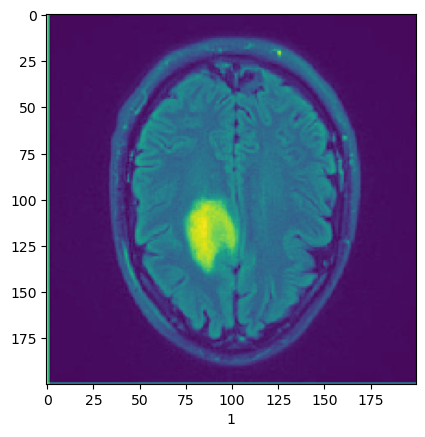

In [203]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


#CNN MODEL

In [204]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_6 (Batc  (None, 198, 198, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_7 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                      

In [205]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [206]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
400/400 [==============================] - 121s 299ms/step - loss: 0.7248 - accuracy: 0.6714 - val_loss: 0.4039 - val_accuracy: 0.7862
Epoch 2/3
400/400 [==============================] - 121s 302ms/step - loss: 0.4508 - accuracy: 0.7572 - val_loss: 0.3167 - val_accuracy: 0.9038
Epoch 3/3
400/400 [==============================] - 118s 295ms/step - loss: 0.3661 - accuracy: 0.8089 - val_loss: 0.1666 - val_accuracy: 0.9438


In [207]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

25/25 - 4s - loss: 0.1666 - accuracy: 0.9438 - 4s/epoch - 157ms/step


In [208]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

25/25 [==============================] - 4s 147ms/step


In [209]:
print(pred1[0:20])

[1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1]


In [210]:
accuracy_score(y_test3D,pred1)

0.94375

a3 =0.9033333333333333
a2 0.9375
a4 0.9541666666666667
a5 0.9575


In [211]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94       378
           1       0.94      0.96      0.95       422

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



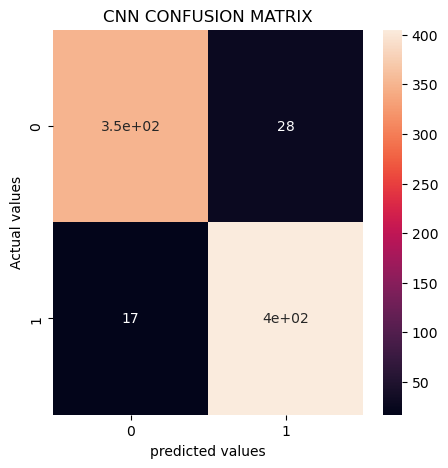

In [212]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [213]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,       # reduce depth
    min_samples_split=5, 
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


rf.fit(x_train2D, y_train2D)



RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [214]:
pred2=rf.predict(x_test2D)

In [215]:
print("validation= ",rf.score(x_train2D,y_train2D))
print("train= ",accuracy_score(y_test2D,pred2))

validation=  0.99875
train=  0.96125



(a3)0.9575
(a2) 0.9508333333333333
a4 0.9508333333333333


In [216]:

conf_mat2=confusion_matrix(y_test2D,pred2)


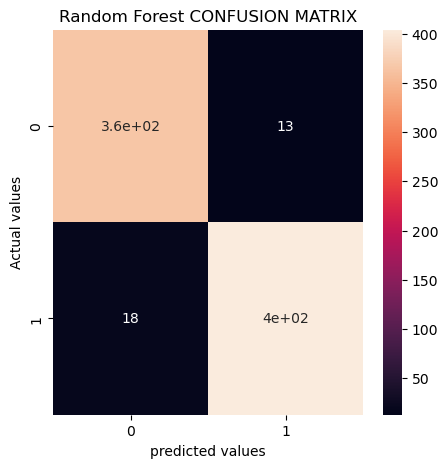

In [217]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [218]:
svm_pipeline = Pipeline([
    ('pca', PCA(n_components=1000)),        # reduce to 500 features
    ('svm', LinearSVC(C=1.0, max_iter=2000, tol=1e-3))  # fewer iterations needed
])

svm_pipeline.fit(x_train2D, y_train2D)
pred3 =svm_pipeline.predict(x_test2D)



c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [219]:
accuracy_score(y_test2D,pred3)

0.89875

(a2)0.9066666666666666

0.9208333333333333(a3)
a4 0.9158333333333334

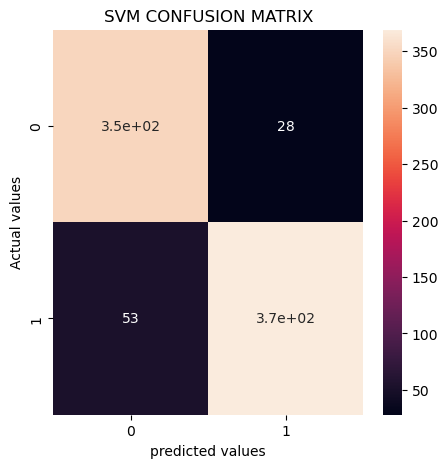

In [220]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [221]:
knn =KNeighborsClassifier(n_neighbors=3, weights='distance',metric= 'manhattan')
knn.fit(x_train2D, y_train2D) 

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [222]:
pred4=knn.predict(x_test2D)

In [223]:
print("Accuracy:", accuracy_score(y_test2D, pred4))

Accuracy: 0.935


 0.9633333333333334 (a3) 
 0.965(a2)
 Accuracy: 0.965 a4


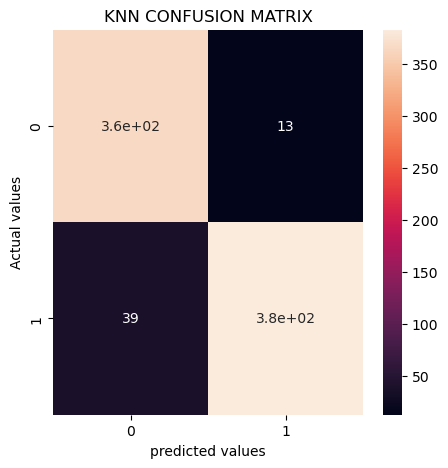

In [224]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [225]:
LR = LogisticRegression(
    C=0.0054,
    class_weight="balanced",
    penalty='l2',
    solver='liblinear',
    max_iter=100
)
LR.fit(x_train2D, y_train2D)

LogisticRegression(C=0.0054, class_weight='balanced', solver='liblinear')

In [226]:
print("Train:", LR.score(x_train2D, y_train2D))
print("Validation:", LR.score(x_test2D, y_test2D))

Train: 0.73546875
Validation: 0.925


 0.93 a3
0.9325 a2
0.93  a4

In [227]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92       378
           1       0.93      0.92      0.93       422

    accuracy                           0.93       800
   macro avg       0.92      0.93      0.92       800
weighted avg       0.93      0.93      0.93       800



Accuracy: 0.9275

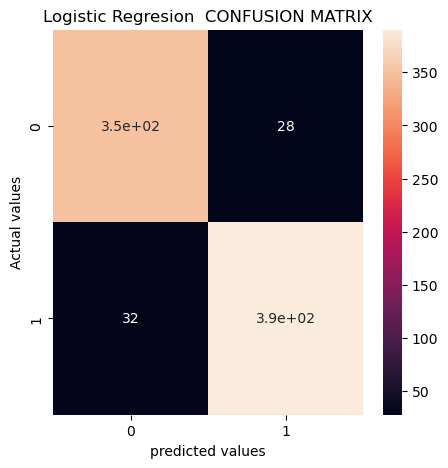

In [228]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

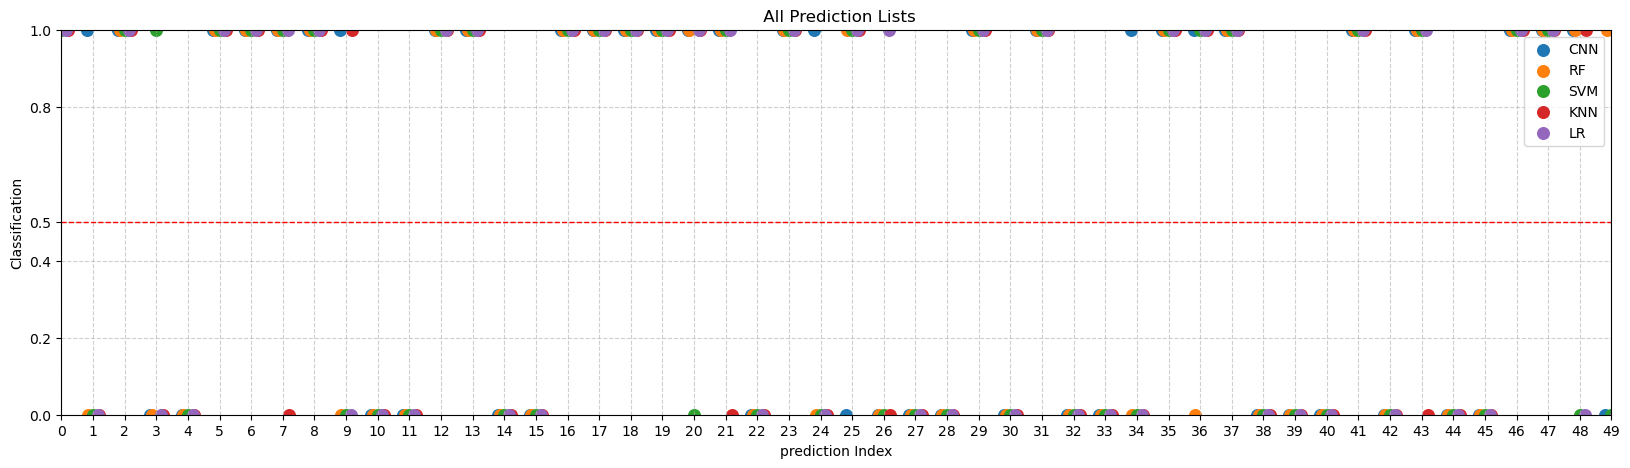

In [229]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [230]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm_pipeline.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

25/25 [==============================] - 4s 147ms/step


In [231]:
print(pp1[0:2])

[1 1]


In [232]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [233]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 0, 1, 0, 0, 1]


In [234]:
print(y_test2D[0:6])

[1 0 1 0 0 1]


In [235]:
print(pred1[0:6])

[1 1 1 0 0 1]


In [236]:
print(pred2[0:6])

[1 0 1 0 0 1]


In [237]:
print(pred3[0:6])

[1 0 1 1 0 1]


In [238]:
print(pred4[0:6])

[1 0 1 0 0 1]


In [239]:
print(pred5[0:6])

[1 0 1 0 0 1]


In [240]:
g=np.where(y_test2D != Ensemble_prediction)[0]
print(g)

[  9  72  92 110 179 184 207 255 282 299 362 382 398 439 458 460 506 509
 596 631 707 719 795]


In [241]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.97125

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       378
           1       0.97      0.97      0.97       422

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



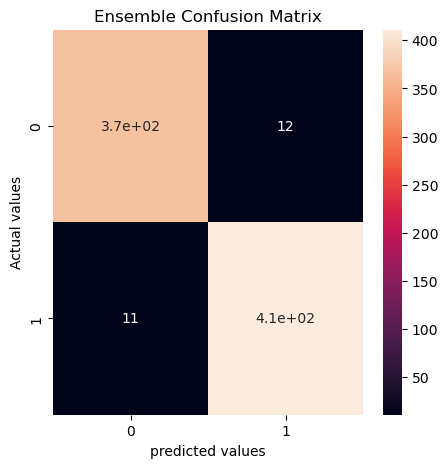

In [242]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [243]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, 0)  
        pic = cv2.resize(pic, (200, 200))                       
        pic = np.array(pic)
        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

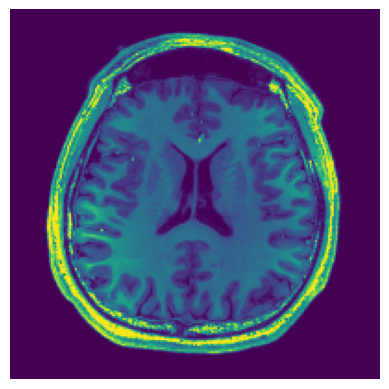

In [244]:
plt.imshow(x_pred[1])
plt.axis('off')

In [245]:
img_path = r"D:\My Final Work\external_pic"
images_cnn = []   
images_flat = []  
filenames = []

for file in os.listdir(img_path):
    path = os.path.join(img_path, file)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 200))
    images_cnn.append(img)
    images_flat.append(img.reshape(-1))
    filenames.append(file)
images_cnn = np.array(images_cnn).reshape(-1, 200, 200, 1) / 255.0
images_flat =np.array(images_flat)/255
pred_cnn = (cnn.predict(images_cnn) > 0.5).astype(int).flatten()
pred_rf  = rf.predict(images_flat)
pred_svm = svm_pipeline.predict(images_flat)
pred_lr  = LR.predict(images_flat)
pred_knn = knn.predict(images_flat)
results = []
for i, name in enumerate(filenames):
    votes = pred_cnn[i] + pred_rf[i] + pred_svm[i] + pred_lr[i] + pred_knn[i]
    if votes >= 3:
        label = "Tumor"
    else:
        label = "No Tumor"

    results.append((name, label))
print("\n Total Predictions:")
for file, label in results:
   print(file + " -------> " + label)



1/1 [==============================] - 0s 141ms/step

 Total Predictions:
h1.jpeg -------> No Tumor
h2.jpg -------> No Tumor
h3.jpeg -------> No Tumor
h4.jpeg -------> Tumor
h5.jpeg -------> No Tumor
h6.jpg -------> No Tumor
t1.jpeg -------> Tumor
t4.jpeg -------> No Tumor
t5.png -------> No Tumor
t6.jpeg -------> Tumor


In [246]:
img_path2 = r"D:\My Final Work\external_pic/t1.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


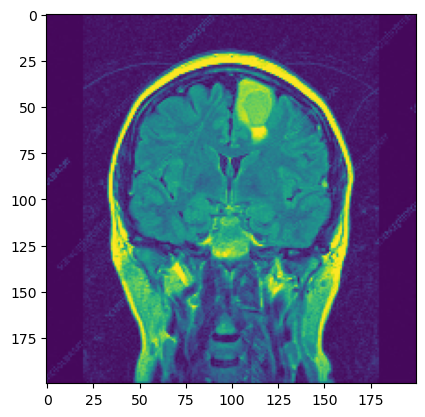

In [247]:
plt.imshow(pic1)

In [248]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [249]:
cnnpred.shape

(1, 200, 200, 1)

In [250]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 31ms/step


In [251]:
print(p11)

[1]


In [252]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [253]:
x_scaled = p_2D/255
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [1]
RF = [0]
SVM = [1]
LR = [1]
KNN = [1]
 
 Tumor
